#  **멀티모달(multi-modal) 학습** 

- **멀티모달 학습**은 텍스트, 이미지, 오디오 등 **다양한 데이터 형식**을 동시에 처리하는 혁신적인 AI 접근 방식

    - 텍스트: 자연어 문장, 문서, 메타데이터
    - 이미지: 사진, 그래프, 차트, 다이어그램
    - 오디오: 음성, 음악, 환경음
    - 비디오: 동영상 시퀀스
    - 센서 데이터: IoT 센서, 생체신호 등

- 인간의 감각 통합 방식과 유사하게 여러 정보 채널을 **동시에 학습**하여 더 깊은 맥락적 이해 제공

- **모달리티별 특화된 신경망** 아키텍처를 사용하여 각 데이터 유형의 고유한 특징을 효과적으로 추출

    - **텍스트 모달리티**: **BERT, GPT** 등의 언어 모델을 활용하여 문맥적 이해와 의미 표현 학습
    - **이미지 모달리티**: **CNN, Vision Transformer**를 통해 시각적 특징 및 패턴 추출
    - **오디오 모달리티**: **웨이브넷, Mel-스펙트로그램** 기반 모델로 음향학적 특성 분석


- 멀티 모달리티 **특징 융합 방법**

    - **Early Fusion**: 입력 단계에서 모달리티 특징을 **직접 결합**하는 방식

    - **Late Fusion**: 각 모달리티를 **개별적으로 처리** 후 최종 결과 통합

    - **Hybrid Fusion**: **다단계 특징 결합**을 통한 유연하고 복합적인 모달리티 통합 접근법

---

`(1) Env 환경변수`

In [1]:
from dotenv import load_dotenv
load_dotenv()

True

`(2) 기본 라이브러리`

In [2]:
import os
from glob import glob

from pprint import pprint
import json

import pandas as pd
import numpy as np

import warnings
warnings.filterwarnings('ignore')

---

## **이미지-텍스트 임베딩 기술**

- **이미지-텍스트 임베딩**의 핵심은 서로 다른 모달리티 데이터를 **공통 벡터 공간에 투영**하는 기술

- 모달리티 간 **의미적 유사성을 벡터로 표현**하여 cross-modal 이해와 분석 가능

- **CLIP 모델**은 이미지와 텍스트를 **의미론적으로 연결**하는 혁신적인 접근 방식 제시

    - OpenAI의 **12명의 연구진**이 개발했으며, 이미지-텍스트 쌍으로 사전 학습
    
    - GPT 모델과 유사하게 **제로샷 학습** 능력을 보유하여 새로운 작업에 빠르게 적용 가능

    - 특정 작업에 대한 **추가 학습 없이** 자연어 기반의 이미지 분석이 가능

    - 논문: https://arxiv.org/abs/2103.00020

### **OpenClip** 소개

- OpenClip은 OpenAI의 CLIP(Contrastive Language-Image Pre-training)을 오픈소스로 구현한 라이브러리

    - 이미지와 텍스트 간의 의미적 유사성 계산
    - 다양한 크기와 성능의 모델 지원
    - 이미지 검색, 분류, 설명 생성 등 다양한 응용 가능

### 1. **필요 라이브러리 설치 및 임포트** 

- 필요한 라이브러리 설치 

- pip install --upgrade --quiet "langchain-experimental<0.4"
- pip install --upgrade --quiet pillow open_clip_torch torch matplotlib

- https://python.langchain.com/docs/integrations/text_embedding/open_clip/

In [3]:
# 이미지 처리를 위한 라이브러리 임포트
import numpy as np
import os
import requests
import matplotlib.pyplot as plt
from PIL import Image
from io import BytesIO
import torch
import open_clip
from langchain_experimental.open_clip import OpenCLIPEmbeddings

# 파이토치 버전 확인
print(torch.__version__)

2.9.0+cpu


### 2. **CLIP 임베딩 모델 로드** 


In [4]:
# 사용 가능한 모델 확인
def check_available_models():
    models = open_clip.list_pretrained()
    print("사용 가능한 모델 목록:")
    for model in models:
        print(f"- {model}")


check_available_models()

사용 가능한 모델 목록:
- ('RN50', 'openai')
- ('RN50', 'yfcc15m')
- ('RN50', 'cc12m')
- ('RN101', 'openai')
- ('RN101', 'yfcc15m')
- ('RN50x4', 'openai')
- ('RN50x16', 'openai')
- ('RN50x64', 'openai')
- ('ViT-B-32', 'openai')
- ('ViT-B-32', 'laion400m_e31')
- ('ViT-B-32', 'laion400m_e32')
- ('ViT-B-32', 'laion2b_e16')
- ('ViT-B-32', 'laion2b_s34b_b79k')
- ('ViT-B-32', 'datacomp_xl_s13b_b90k')
- ('ViT-B-32', 'datacomp_m_s128m_b4k')
- ('ViT-B-32', 'commonpool_m_clip_s128m_b4k')
- ('ViT-B-32', 'commonpool_m_laion_s128m_b4k')
- ('ViT-B-32', 'commonpool_m_image_s128m_b4k')
- ('ViT-B-32', 'commonpool_m_text_s128m_b4k')
- ('ViT-B-32', 'commonpool_m_basic_s128m_b4k')
- ('ViT-B-32', 'commonpool_m_s128m_b4k')
- ('ViT-B-32', 'datacomp_s_s13m_b4k')
- ('ViT-B-32', 'commonpool_s_clip_s13m_b4k')
- ('ViT-B-32', 'commonpool_s_laion_s13m_b4k')
- ('ViT-B-32', 'commonpool_s_image_s13m_b4k')
- ('ViT-B-32', 'commonpool_s_text_s13m_b4k')
- ('ViT-B-32', 'commonpool_s_basic_s13m_b4k')
- ('ViT-B-32', 'commonpool_s_s13m

In [5]:
# 사전 학습된 CLIP 모델 로드

clip_embd_model = OpenCLIPEmbeddings(model_name="ViT-B-16-quickgelu", checkpoint="openai")

clip_embd_model

OpenCLIPEmbeddings(model=CLIP(
  (visual): VisionTransformer(
    (conv1): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16), bias=False)
    (patch_dropout): Identity()
    (ln_pre): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
    (transformer): Transformer(
      (resblocks): ModuleList(
        (0-11): 12 x ResidualAttentionBlock(
          (ln_1): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (attn): MultiheadAttention(
            (out_proj): NonDynamicallyQuantizableLinear(in_features=768, out_features=768, bias=True)
          )
          (ls_1): Identity()
          (ln_2): LayerNorm((768,), eps=1e-05, elementwise_affine=True)
          (mlp): Sequential(
            (c_fc): Linear(in_features=768, out_features=3072, bias=True)
            (gelu): QuickGELU()
            (c_proj): Linear(in_features=3072, out_features=768, bias=True)
          )
          (ls_2): Identity()
        )
      )
    )
    (ln_post): LayerNorm((768,), eps=1e-05, elemen

### 3. **이미지 및 텍스트 임베딩 생성** 

In [6]:
import urllib

# 샘플 이미지 다운로드
urls = [
    "http://images.cocodataset.org/val2017/000000000285.jpg",  # bear
    "http://images.cocodataset.org/val2017/000000039769.jpg",  # cats
    "http://images.cocodataset.org/val2017/000000000776.jpg",  # Teddy bears

]

# 이미지와 비교할 텍스트 쿼리 또는 이미지에 대한 설명 텍스트
texts = ["bear", "cats", "Teddy bears"]  

for url, text in zip(urls, texts):
    fname = text.replace(" ", "_").lower()
    urllib.request.urlretrieve(url, f"{fname}.jpg")


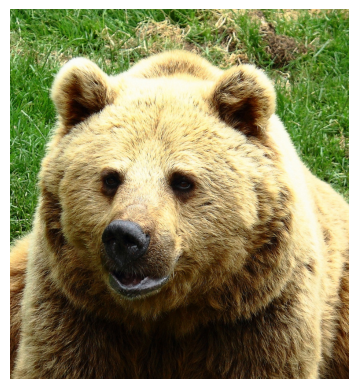

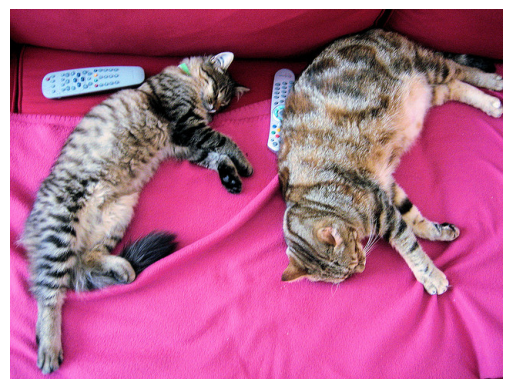

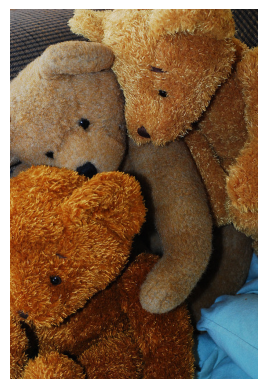

In [7]:
# 이미지 출력
def show_image(image_path):
    image = Image.open(image_path)
    plt.imshow(image)
    plt.axis('off')
    plt.show()

# 이미지 경로
image_paths = [f"{text.replace(' ', '_').lower()}.jpg" for text in texts]

# 이미지 출력
for image_path in image_paths:
    show_image(image_path)

In [8]:
# 이미지와 텍스트 임베딩 생성
img_features = clip_embd_model.embed_image(image_paths)
text_features = clip_embd_model.embed_documents(texts)

# 임베딩을 NumPy 배열로 변환
img_features_np = np.array(img_features)
text_features_np = np.array(text_features)

# 배열의 모양 확인
print("Image features shape:", img_features_np.shape)
print("Text features shape:", text_features_np.shape)

Image features shape: (3, 512)
Text features shape: (3, 512)


In [10]:
text_features

[[-0.007091222330927849,
  -0.018165258690714836,
  -0.019653163850307465,
  0.043198395520448685,
  -0.009955625049769878,
  0.024226421490311623,
  -0.024816522374749184,
  0.01428742054849863,
  0.017683153972029686,
  0.021414052695035934,
  0.015580692328512669,
  -0.012998873367905617,
  0.0120761813595891,
  0.010600992478430271,
  0.01720588281750679,
  -0.009464846923947334,
  -0.005835320800542831,
  -0.010465829633176327,
  -0.004224441945552826,
  0.019835207611322403,
  0.010018733330070972,
  0.0243507269769907,
  -0.031344834715127945,
  -0.0020625966135412455,
  0.00877395085990429,
  -0.0220200028270483,
  0.0026779782492667437,
  0.0030540372245013714,
  0.005513688083738089,
  -0.024167701601982117,
  0.00551583431661129,
  -0.020499281585216522,
  -0.007478879299014807,
  0.03124292939901352,
  0.0735437199473381,
  0.009424081072211266,
  0.01255718432366848,
  -0.009767325595021248,
  0.0307803675532341,
  -0.04200073704123497,
  -0.0012106988579034805,
  -0.04216

Text(0.5, 1.0, 'Cosine Similiarity')

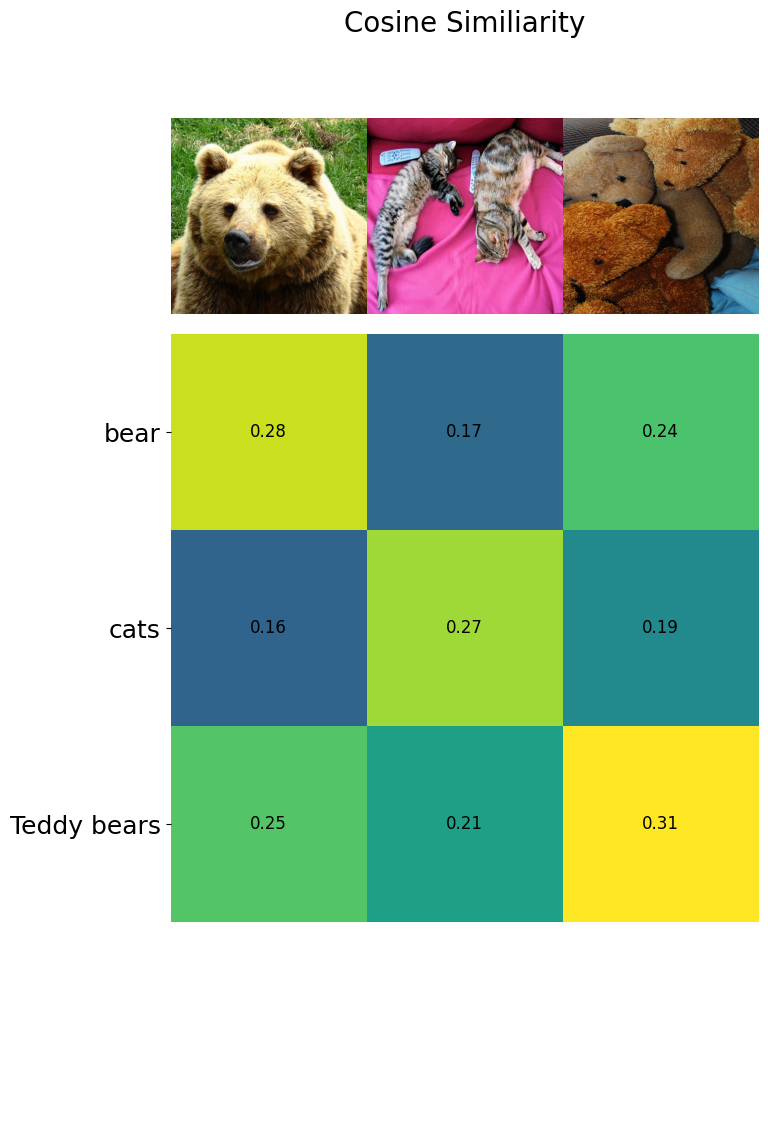

In [11]:
# 이미지-텍스트 유사도 계산 및 시각화
similarity = np.matmul(text_features_np, img_features_np.T)

# 결과 시각화
count = len(texts)
plt.figure(figsize=(20, 14))
plt.imshow(similarity, vmin=0.1, vmax=0.3)
plt.yticks(range(count), texts, fontsize=18)
plt.xticks([])

# 이미지 표시
for i, image in enumerate([Image.open(image_path) for image_path in image_paths]):
    plt.imshow(image, extent=(i - 0.5, i + 0.5, -1.6, -0.6), origin="lower")

# 유사도 점수 표시
for x in range(similarity.shape[1]):
    for y in range(similarity.shape[0]):
        plt.text(x, y, f"{similarity[y, x]:.2f}", ha="center", va="center", size=12)

# 그래프 테두리 제거
for side in ["left", "top", "right", "bottom"]:
    plt.gca().spines[side].set_visible(False)

plt.xlim([-0.5, count - 0.5])
plt.ylim([count + 0.5, -2])
plt.title("Cosine Similiarity", size=20)

# ~ 20:30분까지 실습

---

## **UNSPLASH 데이터셋을 활용한 이미지 검색**

- **Faiss** 라이브러리를 활용하여 **대규모 이미지 검색**을 구현

- Faiss **인덱스**를 파일로 저장하고 필요할 때 로드하는 방식으로 메모리를 관리

- **유사도 검색** 알고리즘으로 대규모 데이터셋에서도 빠른 검색이 가능

### 1. **필요 라이브러리 설치** 

- faiss-cpu 설치 (GPU 사용 시 faiss-gpu 설치)
- pip install faiss-cpu sentence-transformers 

In [12]:
import os
import zipfile
from tqdm.autonotebook import tqdm
from PIL import Image
import requests
import torch
import numpy as np
import faiss 
import pickle
from IPython.display import display
from sentence_transformers import util

### 2. **UNSPLASH 이미지 데이터셋 준비** 

In [ ]:
# 이미지 다운로드 
img_folder = 'unsplash/'
if not os.path.exists(img_folder) or len(os.listdir(img_folder)) == 0:
    os.makedirs(img_folder, exist_ok=True)
    photo_filename = 'unsplash-25k-photos.zip'
    if not os.path.exists(photo_filename):
        util.http_get('http://sbert.net/datasets/'+photo_filename, photo_filename) # sentence-transformers util 사용
    with zipfile.ZipFile(photo_filename, 'r') as zf:
        for member in tqdm(zf.infolist(), desc='Extracting'):
            zf.extract(member, img_folder)

# 이미지 파일 경로 리스트 생성
img_files = glob(os.path.join(img_folder, '*.jpg'))

# 이미지 파일 경로 리스트 확인
print(f'이미지 파일 개수: {len(img_files)}')
print(img_files[:5])

 47%|████▋     | 895M/1.92G [10:07<10:29, 1.63MB/s]   

KeyboardInterrupt: 

 47%|████▋     | 895M/1.92G [10:20<10:29, 1.63MB/s]

### 3. **FAISS 인덱스에 임베딩 저장** 

In [15]:
# 이미지 파일 경로 리스트 생성
img_files = glob(os.path.join(img_folder, '*.jpg'))

# 이미지 파일 경로 리스트 확인
print(f'이미지 파일 개수: {len(img_files)}')
print(img_files[:5])

이미지 파일 개수: 24996
['unsplash/5TpBhNBPAE8.jpg', 'unsplash/2-phOrgQnuY.jpg', 'unsplash/O_uHS1bru2k.jpg', 'unsplash/6ppUnVEUHpU.jpg', 'unsplash/B4XBE_W8sJI.jpg']


In [16]:
# 임베딩 모델 로드
clip_embd_model = OpenCLIPEmbeddings(model_name="ViT-B-16-quickgelu", checkpoint="openai")

# 이미지 폴더에서 이미지를 불러와서 임베딩을 계산하고 FIASS에 저장 
# 테스트를 위해 1000개의 이미지만 사용하는 것으로 수정 (전체 이미지 사용 시 시간이 오래 걸릴 수 있음)

img_files = img_files[:1000]

# 이미지 임베딩 계산 - batch 처리
img_embeddings = []
batch_size = 100
for i in tqdm(range(0, len(img_files), batch_size), desc='Calculating Image Embeddings'):
    batch_files = img_files[i:i+batch_size]
    batch_embeddings = clip_embd_model.embed_image(batch_files)
    img_embeddings.append(batch_embeddings)

# 이미지 임베딩을 NumPy 배열로 변환
img_embeddings = np.vstack(img_embeddings)

# 이미지 임베딩의 크기 확인
print(f'Image Embeddings Shape: {img_embeddings.shape}')

Calculating Image Embeddings: 100%|██████████| 10/10 [01:11<00:00,  7.12s/it]

Image Embeddings Shape: (1000, 512)


In [17]:
# FAISS 인덱스 생성
index = faiss.IndexFlatL2(img_embeddings.shape[1])
index.add(img_embeddings)  # 이미지 임베딩 추가

# FAISS 인덱스 저장
faiss.write_index(index, 'img_embeddings.index')

In [18]:
# FAISS 인덱스 로드
index = faiss.read_index('img_embeddings.index')

# FAISS 인덱스 확인
print(f"FAISS index: {index}")

FAISS index: <faiss.swigfaiss.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0xffff07c26400> >


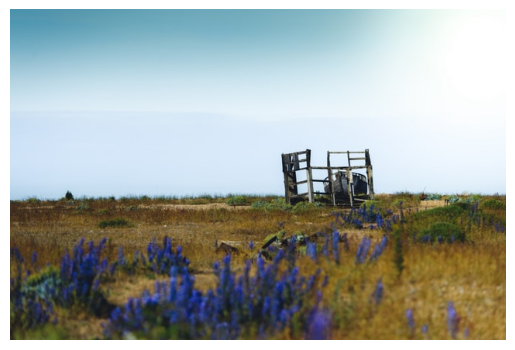

In [19]:
# FAISS 인덱스에서 가장 가까운 k개의 이웃 검색
def search_similar_images(query_image_path, k):
    # 이미지 임베딩 생성
    query_embedding = clip_embd_model.embed_image([query_image_path])
    
    # 리스트를 numpy 배열로 변환
    query_embedding = np.array(query_embedding, dtype=np.float32)
    
    # FAISS 인덱스에서 가장 가까운 k개의 이웃 검색
    distances, indices = index.search(query_embedding, k)
    
    # 결과 반환
    return distances[0], indices[0]


# 쿼리 이미지 경로
query_image_path = img_files[0]  # 첫 번째 이미지 사용

# 쿼리 이미지 출력
show_image(query_image_path)

유사한 이미지 1: unsplash/5TpBhNBPAE8.jpg (거리: 0.0000)


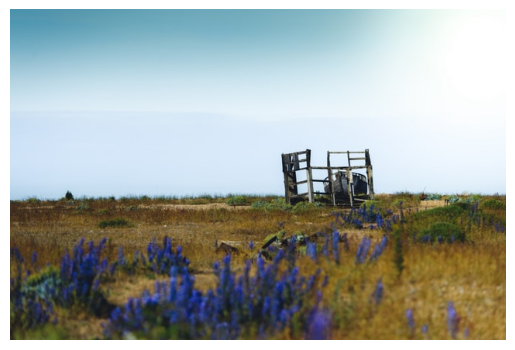

유사한 이미지 2: unsplash/pH3io2getLQ.jpg (거리: 0.3052)


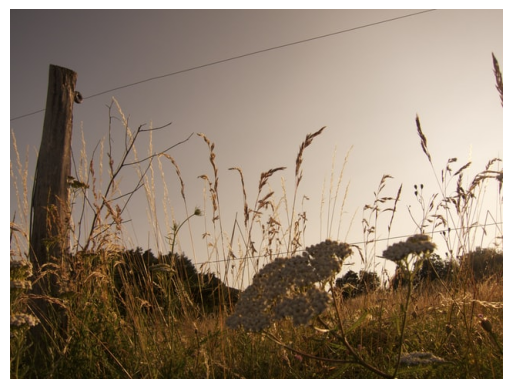

유사한 이미지 3: unsplash/XwM_9Hx7lXE.jpg (거리: 0.3345)


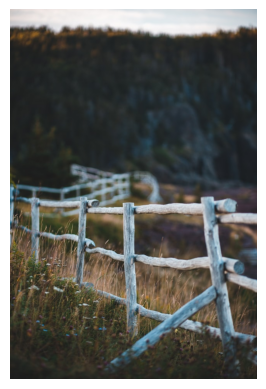

유사한 이미지 4: unsplash/-rSka4Bw-EU.jpg (거리: 0.3360)


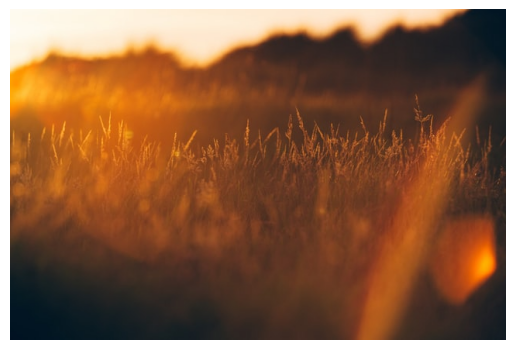

유사한 이미지 5: unsplash/pfsoBr7m6W4.jpg (거리: 0.3383)


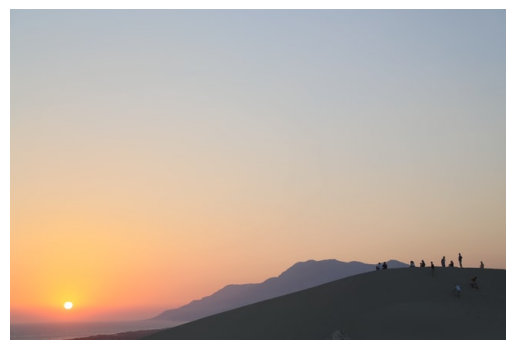

In [20]:
# 유사한 이미지 검색
distances, indices = search_similar_images(query_image_path, k=5)

# 유사한 이미지 출력
for i, idx in enumerate(indices):
    print(f"유사한 이미지 {i+1}: {img_files[idx]} (거리: {distances[i]:.4f})")
    show_image(img_files[idx])

텍스트 쿼리: a black dog running in the park
유사한 이미지 1: unsplash/lwq2JoVRDwc.jpg (거리: 1.4611)


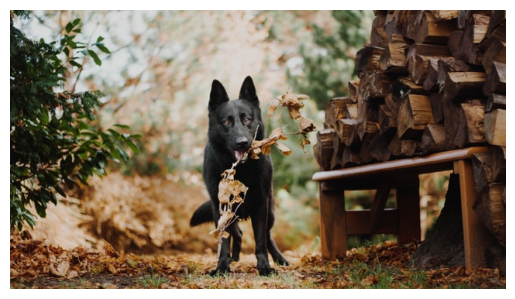

유사한 이미지 2: unsplash/UFT6ZjbmrX0.jpg (거리: 1.4743)


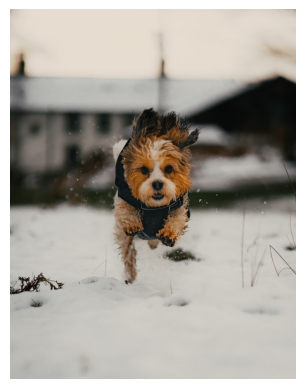

유사한 이미지 3: unsplash/Z_yoZNHQlF0.jpg (거리: 1.4777)


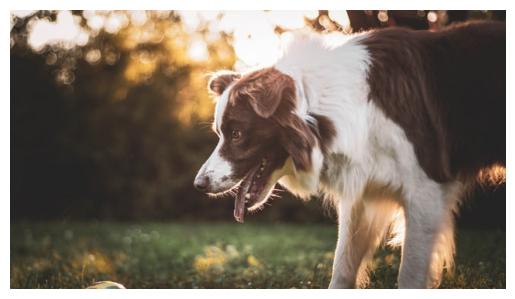

유사한 이미지 4: unsplash/wuGnv4fFbpA.jpg (거리: 1.4802)


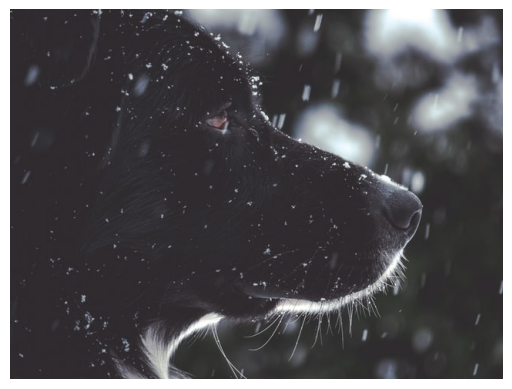

유사한 이미지 5: unsplash/4XyK86k2i90.jpg (거리: 1.4814)


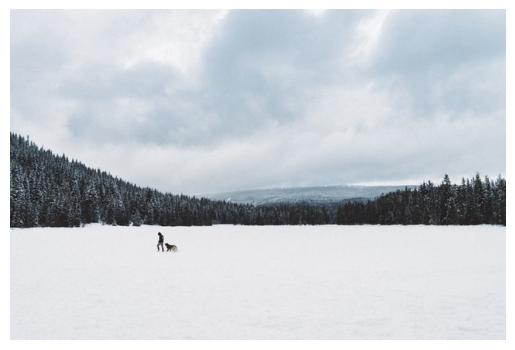

텍스트 쿼리: 공원에서 달리는 검은 개
유사한 이미지 1: unsplash/-JrQwyTEIt0.jpg (거리: 1.5097)


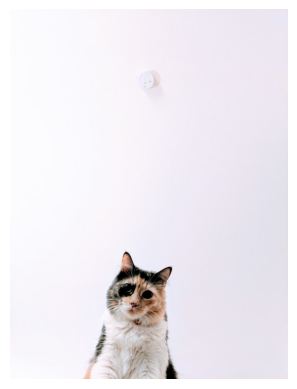

유사한 이미지 2: unsplash/dhOaokGswrw.jpg (거리: 1.5122)


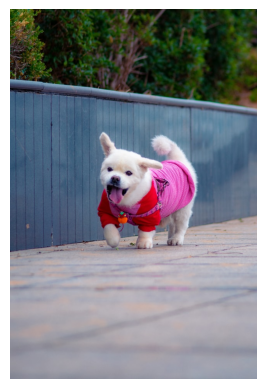

유사한 이미지 3: unsplash/g4uAI6e47v8.jpg (거리: 1.5174)


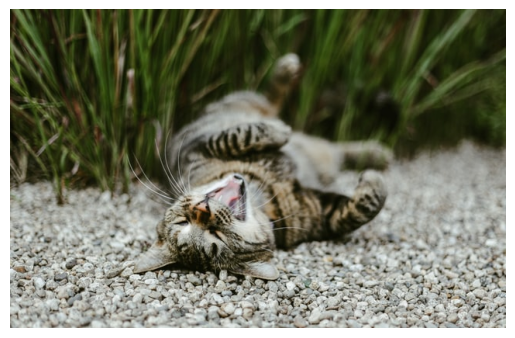

유사한 이미지 4: unsplash/2krpK2Rrfn4.jpg (거리: 1.5184)


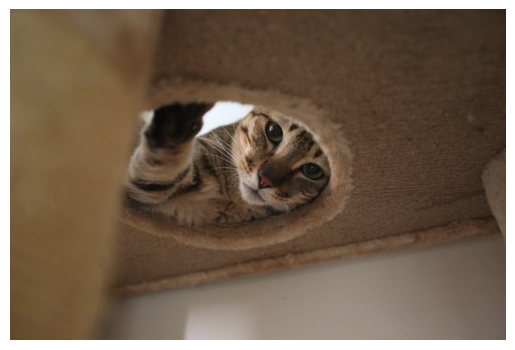

유사한 이미지 5: unsplash/7vvID1j3MqU.jpg (거리: 1.5317)


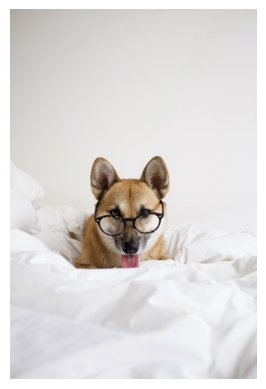

In [21]:
# 텍스트 쿼리 임베딩 생성
text_queries = [
    "a black dog running in the park",
    "공원에서 달리는 검은 개",
]

# FAISS 인덱스에서 가장 가까운 k개의 이웃 검색
def search_similar_images_by_text(text_query, k):
    # 텍스트 쿼리 임베딩 생성
    text_embedding = clip_embd_model.embed_documents([text_query])
    
    # 리스트를 numpy 배열로 변환
    text_embedding = np.array(text_embedding, dtype=np.float32)
    
    # FAISS 인덱스에서 가장 가까운 k개의 이웃 검색
    distances, indices = index.search(text_embedding, k)
    
    # 결과 반환
    return distances[0], indices[0]


# 텍스트 쿼리 이미지 검색
for text_query in text_queries:
    print(f"텍스트 쿼리: {text_query}")
    
    # 유사한 이미지 검색
    distances, indices = search_similar_images_by_text(text_query, k=5)
    
    # 유사한 이미지 출력
    for i, idx in enumerate(indices):
        print(f"유사한 이미지 {i+1}: {img_files[idx]} (거리: {distances[i]:.4f})")
        show_image(img_files[idx])

---
## [실습] 

- 다른 텍스트를 이용해서 이미지를 검색하고, 그 결과를 분석하세요. 



In [ ]:
# 여기에 코드를 작성하세요. 

---
## [심화] ~ 21:39분까지 실습

- 다국어 지원하는 CLIP 모델을 사용하여, FAISS 인덱스를 생성합니다. (예: xlm-roberta-base-ViT-B-32)
    - **XLM-RoBERTa**는 Facebook AI에서 개발한 다국어 언어 모델로, 100개 언어에 대해 사전 학습
    - **ViT-B/32**는 이미지 처리용 Vision Transformer로, B는 모델 크기(Base), 32는 패치 크기를 의미
    - **OpenCLIP**에서는 XLM-RoBERTa를 텍스트 인코더로, ViT를 이미지 인코더로 조합하여 사용

- 영어, 한국어 쿼리에 대한 이미지 검색을 수행합니다. 

In [ ]:
# 여기에 코드를 작성하세요.

In [22]:
# 임베딩 모델 로드
clip_embd_model = OpenCLIPEmbeddings(model_name="xlm-roberta-base-ViT-B-32", checkpoint="laion5b_s13b_b90k")

# 이미지 파일 경로 리스트 생성
img_files = glob(os.path.join(img_folder, '*.jpg'))

# 이미지 파일 경로 리스트 확인
print(f'이미지 파일 개수: {len(img_files)}')

# 이미지 임베딩 계산 - batch 처리
img_embeddings = []
batch_size = 100
for i in tqdm(range(0, len(img_files), batch_size), desc='Calculating Image Embeddings'):
    batch_files = img_files[i:i+batch_size]
    batch_embeddings = clip_embd_model.embed_image(batch_files)
    img_embeddings.append(batch_embeddings)

# 이미지 임베딩을 NumPy 배열로 변환
img_embeddings = np.vstack(img_embeddings)

# 이미지 임베딩의 크기 확인
print(f'Image Embeddings Shape: {img_embeddings.shape}')

# FAISS 인덱스 생성
index = faiss.IndexFlatL2(img_embeddings.shape[1])
index.add(img_embeddings)  # 이미지 임베딩 추가

# FAISS 인덱스 저장
faiss.write_index(index, 'multilingual_img_embeddings.index')

# FAISS 인덱스 로드
index = faiss.read_index('multilingual_img_embeddings.index')

# FAISS 인덱스 확인
print(f"FAISS index: {index}")

 47%|████▋     | 895M/1.92G [50:41<58:09, 294kB/s] 


이미지 파일 개수: 24996


Calculating Image Embeddings: 100%|██████████| 250/250 [13:33<00:00,  3.25s/it]


Image Embeddings Shape: (24996, 512)
FAISS index: <faiss.swigfaiss.IndexFlatL2; proxy of <Swig Object of type 'faiss::IndexFlatL2 *' at 0xffff07cf6fa0> >


텍스트 쿼리: a black dog running in the park
유사한 이미지 1: unsplash/4X-3nYIKgFM.jpg (거리: 1.4542)


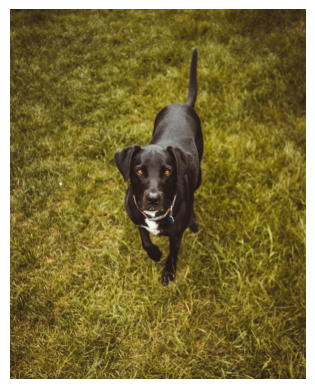

유사한 이미지 2: unsplash/NLZdDzplC8c.jpg (거리: 1.4594)


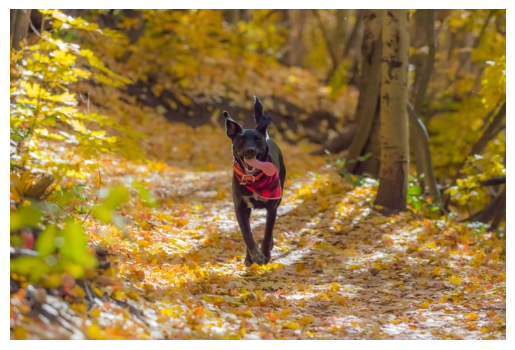

유사한 이미지 3: unsplash/g6YNrpOq1Gk.jpg (거리: 1.4619)


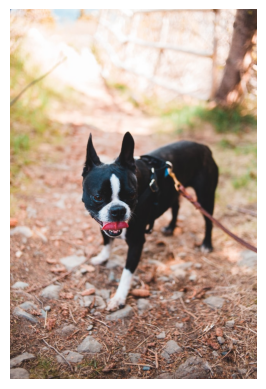

유사한 이미지 4: unsplash/4_5ao9QNI38.jpg (거리: 1.4676)


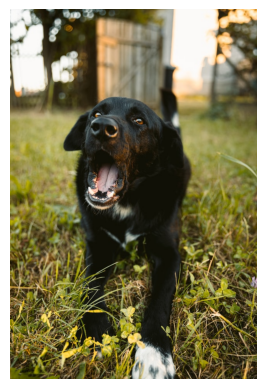

유사한 이미지 5: unsplash/pFg2jpJRWwM.jpg (거리: 1.4746)


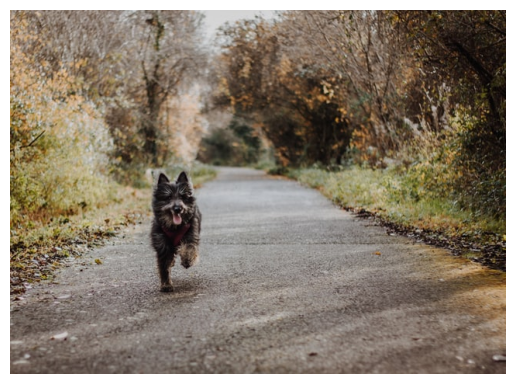

텍스트 쿼리: 공원에서 달리는 검은 개
유사한 이미지 1: unsplash/4X-3nYIKgFM.jpg (거리: 1.4561)


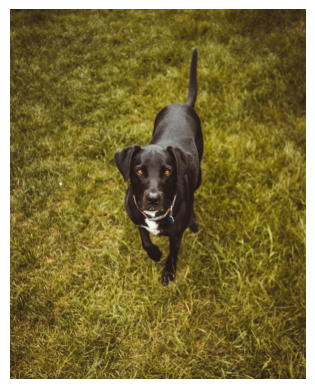

유사한 이미지 2: unsplash/NLZdDzplC8c.jpg (거리: 1.4693)


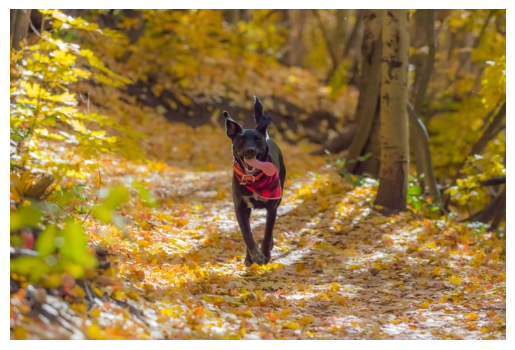

유사한 이미지 3: unsplash/4_5ao9QNI38.jpg (거리: 1.4791)


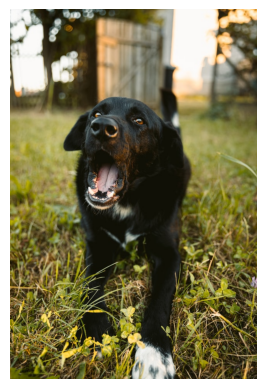

유사한 이미지 4: unsplash/g6YNrpOq1Gk.jpg (거리: 1.4819)


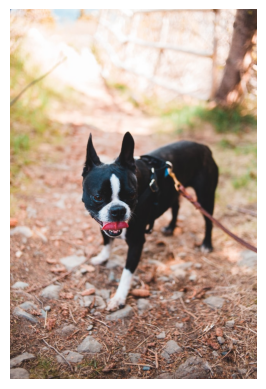

유사한 이미지 5: unsplash/oTTtl-bV7Z8.jpg (거리: 1.4868)


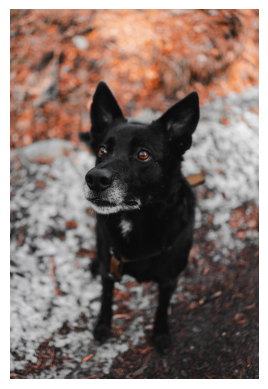

In [23]:
# 텍스트 쿼리 임베딩 생성
text_queries = [
    "a black dog running in the park",
    "공원에서 달리는 검은 개",
]

# FAISS 인덱스에서 가장 가까운 k개의 이웃 검색
def search_similar_images_by_text(text_query, k):
    # 텍스트 쿼리 임베딩 생성
    text_embedding = clip_embd_model.embed_documents([text_query])
    
    # 리스트를 numpy 배열로 변환
    text_embedding = np.array(text_embedding, dtype=np.float32)
    
    # FAISS 인덱스에서 가장 가까운 k개의 이웃 검색
    distances, indices = index.search(text_embedding, k)
    
    # 결과 반환
    return distances[0], indices[0]


# 텍스트 쿼리 이미지 검색
for text_query in text_queries:
    print(f"텍스트 쿼리: {text_query}")
    
    # 유사한 이미지 검색
    distances, indices = search_similar_images_by_text(text_query, k=5)
    
    # 유사한 이미지 출력
    for i, idx in enumerate(indices):
        print(f"유사한 이미지 {i+1}: {img_files[idx]} (거리: {distances[i]:.4f})")
        show_image(img_files[idx])
